Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2


Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:22:58.102' from MJD-AVG.
Set DATE-END to '2024-09-08T12:35:44.015' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.810003 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291940033.618 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.49145905084584e-10 deg2
9.491458943030916e-10 deg2
9.49145885655769e-10 deg2
9.491458757317268e-10 deg2


Set OBSGEO-B to    -3.785099 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291756623.231 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


7.524574264515582e-11 deg2
Finite values in color1: 15344, color2: 12547
Finite values in both colors: 7633
1.4 um 1.62 um 2.1 um 4.1 um
1.4 um 1.62 um 2.1 um 4.1 um
7.0412946428571415 5.4357638888888875 3.6726315789473687 1.172645403377111


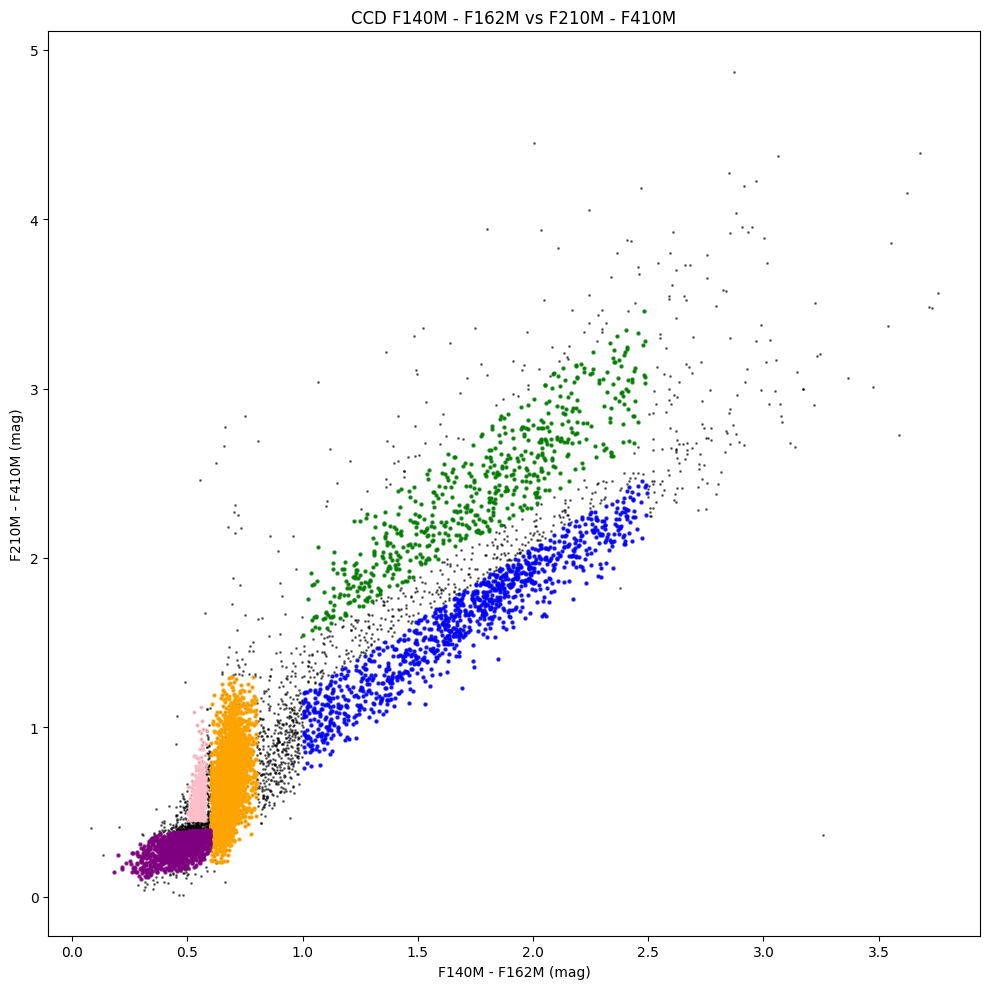

In [16]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89
def get_mag(catalog, ww, filtername='f140m'):
    print(ww.proj_plane_pixel_area())
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])
    if wav < 500:

        zeropoint = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
    abmag = -2.5 * np.log10(flux / zeropoint) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog.fits')

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89

ext = RL85_MWGC()
def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=30, start=None,
                    color='y', head_width=0.5, color1_data=None, color2_data=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_color2 = np.nanmean(color2_data)
        std_color1 = np.nanstd(color1_data)
        std_color2 = np.nanstd(color2_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        if e_3 - e_4 < 0:
            std_color2 *= -1
    
        start2 = (mean_color1 + 2*std_color1, mean_color2 + 2*std_color2)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)


imgsavedir = '/orange/adamginsburg/web/secure/taehwa/ccds2/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

# Generate unique color combinations
from itertools import combinations

# make plot of color color diagram of f140m - f162m vs f210m - f410m
color1_pair = ('f140m', 'f162m')
color2_pair = ('f210m', 'f410m')
f1, f2 = color1_pair
f3, f4 = color2_pair



# Calculate colors
color1 = (filters[f1][0] - filters[f2][0]).value
color2 = (filters[f3][0] - filters[f4][0]).value

# pritn the number of finite value of color1 and color2
print(f"Finite values in color1: {np.isfinite(color1).sum()}, color2: {np.isfinite(color2).sum()}")
#also print the number of finite values in both color1 and color2
finite_both = np.isfinite(color1) & np.isfinite(color2)
print(f"Finite values in both colors: {finite_both.sum()}")

# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.scatter(color1, color2, s=1, c='black', alpha=0.5)

ax.set_xlabel(f'{f1.upper()} - {f2.upper()} (mag)')
ax.set_ylabel(f'{f3.upper()} - {f4.upper()} (mag)')
ax.set_title(f'CCD {f1.upper()} - {f2.upper()} vs {f3.upper()} - {f4.upper()}')

# get 2sigma outside position of color1 and color2
c1_mean = np.nanmean(color1)
c1_std = np.nanstd(color1)
c2_mean = np.nanmean(color2)
c2_std = np.nanstd(color2)


# Add extinction vector and use 2sigma position as start point
plot_extvec_ccd(ax, color1=(f1, f2), color2=(f3, f4), 
                ext=ext, extvec_scale=30, color='r',color1_data=color1, color2_data=color2)
                #start=(c1_mean + 2*c1_std, c2_mean + 2*c2_std), color='r')

plt.tight_layout()
# make the subset in the color-color diagram encompassed by polygons made of vertices
vertices1 = [(1.0, 1.2), (2.5, 2.5), (2.5, 2.0), (1.0, 0.5)]
vertices2 = [(1.0, 1.5), (1.0, 2.0), (2.5, 3.5), (2.5, 2.7)]
vertices3 = [(0.6, 0.2), (0.6, 1.3), (0.8, 1.3), (0.8, 0.2)]
vertices4 = [(0,0), (0.6, 0.2), (0.6, 0.4), (0.2, 0.35)]
vertices5 = [(0.5, 0.45), (0.5, 1.2), (0.58, 1.2), (0.58, 0.45)]

# mark the points in the polygon area in the plot with differnt colors
from matplotlib.path import Path
path1 = Path(vertices1)
path2 = Path(vertices2) 
path3 = Path(vertices3)
path4 = Path(vertices4)
path5 = Path(vertices5)
points = np.vstack((color1, color2)).T
inside1 = path1.contains_points(points)
inside2 = path2.contains_points(points) 
inside3 = path3.contains_points(points)
inside4 = path4.contains_points(points)
inside5 = path5.contains_points(points)
ax.scatter(color1[inside1], color2[inside1], s=5, c='blue', alpha=0.7, label='lower branch')
ax.scatter(color1[inside2], color2[inside2], s=5, c='green', alpha=0.7, label='upper branch')
ax.scatter(color1[inside3], color2[inside3], s=5, c='orange', alpha=0.7, label='main sequence')
ax.scatter(color1[inside4], color2[inside4], s=5, c='purple', alpha=0.7, label='lower left')
ax.scatter(color1[inside5], color2[inside5], s=5, c='pink', alpha=0.7, label='subsequence on the left')



Finite values in color1: 15344, color2: 12547
Finite values in both colors: 7633
1.4 um 1.62 um 2.1 um 4.1 um
1.4 um 1.62 um 2.1 um 4.1 um
7.0412946428571415 5.4357638888888875 3.6726315789473687 1.172645403377111


(0.0, 1.5)

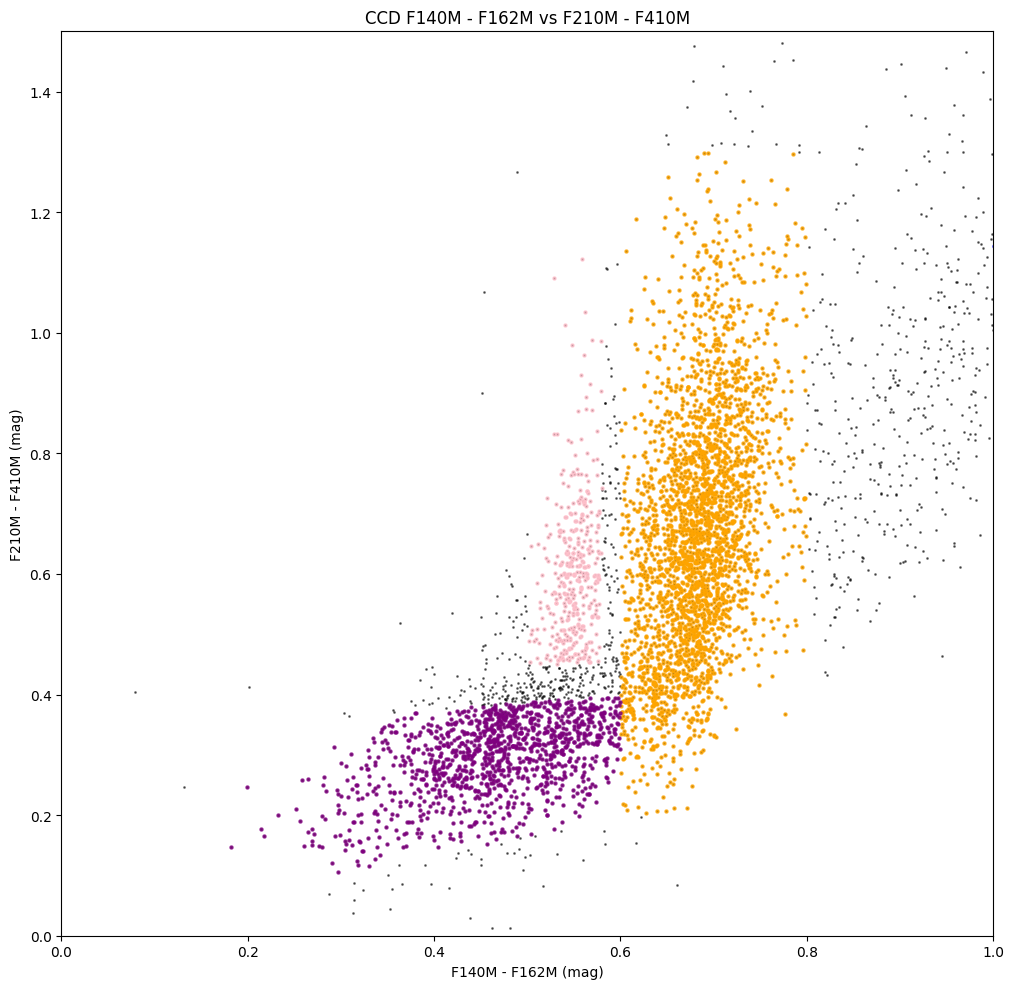

In [17]:

# make plot of color color diagram of f140m - f162m vs f210m - f410m
color1_pair = ('f140m', 'f162m')
color2_pair = ('f210m', 'f410m')
f1, f2 = color1_pair
f3, f4 = color2_pair



# Calculate colors
color1 = (filters[f1][0] - filters[f2][0]).value
color2 = (filters[f3][0] - filters[f4][0]).value

# pritn the number of finite value of color1 and color2
print(f"Finite values in color1: {np.isfinite(color1).sum()}, color2: {np.isfinite(color2).sum()}")
#also print the number of finite values in both color1 and color2
finite_both = np.isfinite(color1) & np.isfinite(color2)
print(f"Finite values in both colors: {finite_both.sum()}")

# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

ax.scatter(color1, color2, s=1, c='black', alpha=0.5)

ax.set_xlabel(f'{f1.upper()} - {f2.upper()} (mag)')
ax.set_ylabel(f'{f3.upper()} - {f4.upper()} (mag)')
ax.set_title(f'CCD {f1.upper()} - {f2.upper()} vs {f3.upper()} - {f4.upper()}')

# get 2sigma outside position of color1 and color2
c1_mean = np.nanmean(color1)
c1_std = np.nanstd(color1)
c2_mean = np.nanmean(color2)
c2_std = np.nanstd(color2)


# Add extinction vector and use 2sigma position as start point
plot_extvec_ccd(ax, color1=(f1, f2), color2=(f3, f4), 
                ext=ext, extvec_scale=30, color='r',color1_data=color1, color2_data=color2)
                #start=(c1_mean + 2*c1_std, c2_mean + 2*c2_std), color='r')

plt.tight_layout()
# make the subset in the color-color diagram encompassed by polygons made of vertices
vertices1 = [(1.0, 1.2), (2.5, 2.5), (2.5, 2.0), (1.0, 0.5)]
vertices2 = [(1.0, 1.5), (1.0, 2.0), (2.5, 3.5), (2.5, 2.7)]
vertices3 = [(0.6, 0.2), (0.6, 1.3), (0.8, 1.3), (0.8, 0.2)]
vertices4 = [(0,0), (0.6, 0.2), (0.6, 0.4), (0.2, 0.35)]
vertices5 = [(0.5, 0.45), (0.5, 1.2), (0.58, 1.2), (0.58, 0.45)]

# mark the points in the polygon area in the plot with differnt colors
from matplotlib.path import Path
path1 = Path(vertices1)
path2 = Path(vertices2) 
path3 = Path(vertices3)
path4 = Path(vertices4)
path5 = Path(vertices5)
points = np.vstack((color1, color2)).T
inside1 = path1.contains_points(points)
inside2 = path2.contains_points(points) 
inside3 = path3.contains_points(points)
inside4 = path4.contains_points(points)
inside5 = path5.contains_points(points)
ax.scatter(color1[inside1], color2[inside1], s=5, c='blue', alpha=0.7, label='lower branch')
ax.scatter(color1[inside2], color2[inside2], s=5, c='green', alpha=0.7, label='upper branch')
ax.scatter(color1[inside3], color2[inside3], s=5, c='orange', alpha=0.7, label='main sequence')
ax.scatter(color1[inside4], color2[inside4], s=5, c='purple', alpha=0.7, label='lower left')
ax.scatter(color1[inside5], color2[inside5], s=5, c='pink', alpha=0.7, label='subsequence on the left')
ax.set_xlim(0,1)
ax.set_ylim(0,1.5)




In [18]:
# save tables with subsets 
subset_lower_branch = catalog[inside1]
subset_upper_branch = catalog[inside2]
subset_main_sequence = catalog[inside3]
subset_lower_left = catalog[inside4]
subset_subsequence_left = catalog[inside5]
subset_lower_branch.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/ccds_subsets/subset_lower_branch.fits', overwrite=True)
subset_upper_branch.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/ccds_subsets/subset_upper_branch.fits', overwrite=True)
subset_main_sequence.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/ccds_subsets/subset_main_sequence.fits', overwrite=True)
subset_lower_left.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/ccds_subsets/subset_lower_left.fits', overwrite=True)
subset_subsequence_left.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/ccds_subsets/subset_subsequence_left.fits', overwrite=True) 

(24.530196295027864, 5.976424585798058)

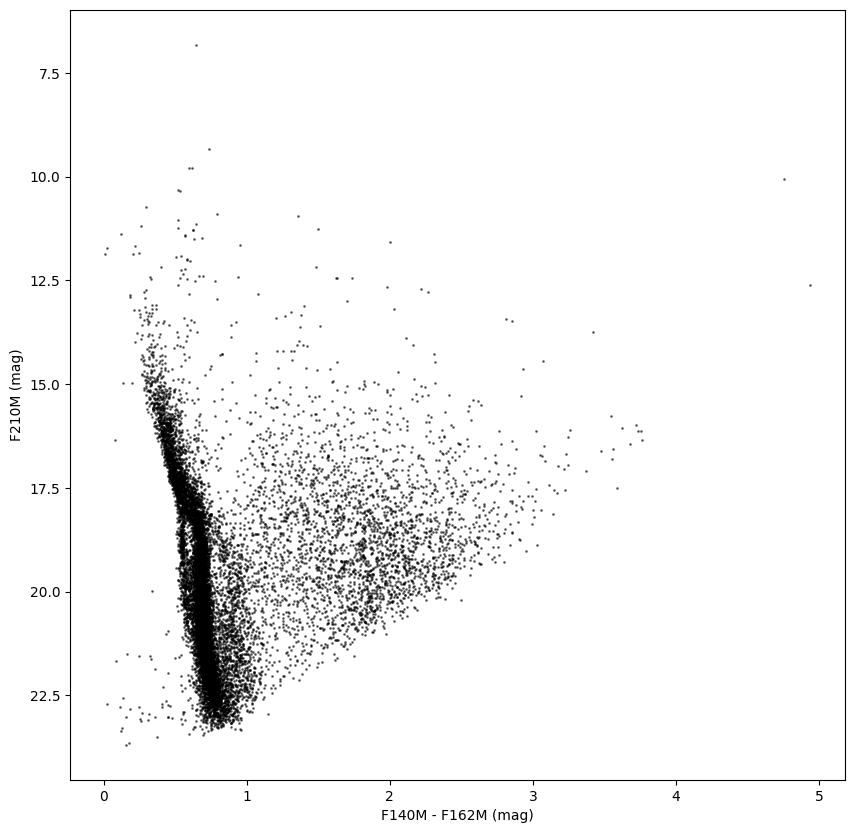

In [21]:
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2[0] + (e_1 - e_2), start2[1] + (e_3 - e_4)),
                xytext=(start2[0], start2[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
color1_pair = ('f140m', 'f162m')
mag1 = ('f210m',)
f1, f2 = color1_pair
f3 = mag1[0]

# Calculate colors
color1 = (filters[f1][0] - filters[f2][0]).value
mag1 = (filters[f3][0]).value 
ax.scatter(color1, mag1, s=1, c='black', alpha=0.5)
ax.set_xlabel(f'{f1.upper()} - {f2.upper()} (mag)')
ax.set_ylabel(f'{f3.upper()} (mag)')
ax.set_ylim(ax.get_ylim()[::-1])  # Invert y-axis for magnitudes

(24.530196295027864, 5.976424585798058)

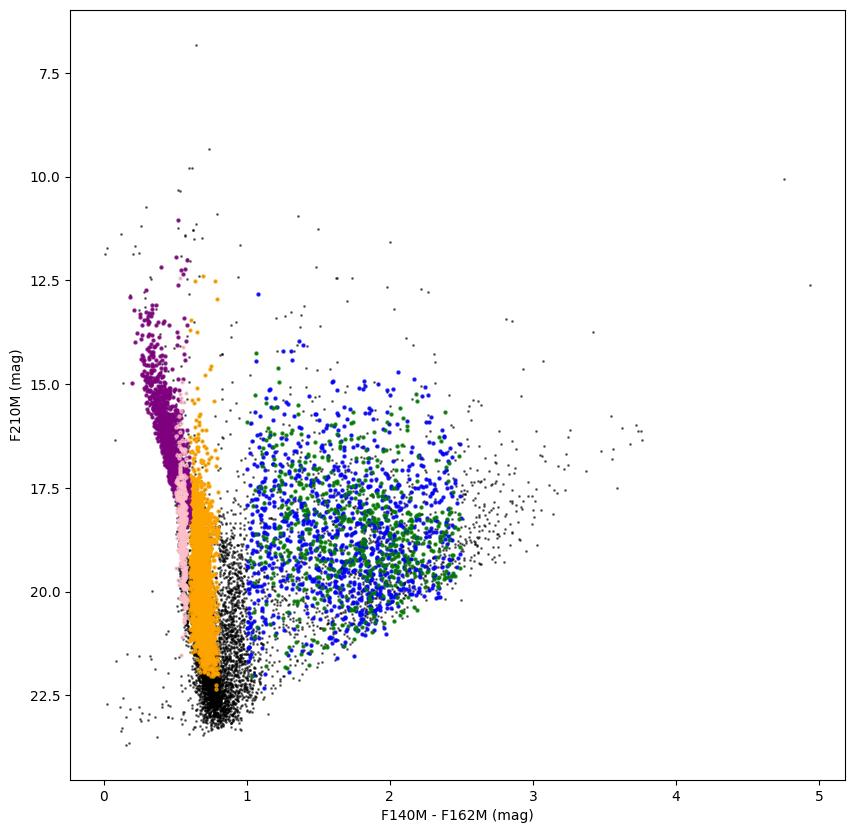

In [20]:
# plot the same color magnutide diagram but plot with different colors for the subsets defined above

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
color1_pair = ('f140m', 'f162m')
mag1 = ('f210m',)
f1, f2 = color1_pair
f3 = mag1[0]

# Calculate colors
color1 = (filters[f1][0] - filters[f2][0]).value
mag1 = (filters[f3][0]).value 
ax.scatter(color1, mag1, s=1, c='black', alpha=0.5)
ax.set_xlabel(f'{f1.upper()} - {f2.upper()} (mag)')
ax.set_ylabel(f'{f3.upper()} (mag)')
ax.scatter(color1[inside1], mag1[inside1], s=5, c='blue', alpha=0.7, label='lower branch')
ax.scatter(color1[inside2], mag1[inside2], s=5, c='green', alpha=0.7, label='upper branch')
ax.scatter(color1[inside3], mag1[inside3], s=5, c='orange', alpha=0.7, label='main sequence')
ax.scatter(color1[inside4], mag1[inside4], s=5, c='purple', alpha=0.7, label='lower left')
ax.scatter(color1[inside5], mag1[inside5], s=5, c='pink', alpha=0.7, label='subsequence on the left')

ax.set_ylim(ax.get_ylim()[::-1])  # Reverse y-axis for magnitude


(21.900005168911463, 8.973455325580849)

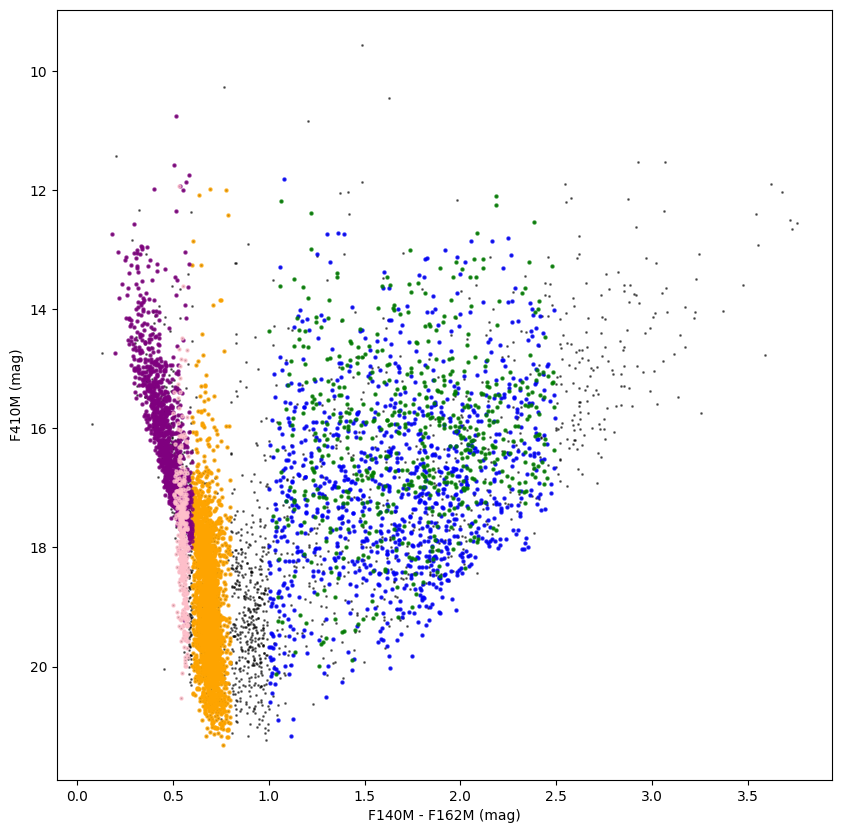

In [22]:
# plot the same color magnutide diagram but plot with different colors for the subsets defined above

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
color1_pair = ('f140m', 'f162m')
mag1 = ('f410m',)
f1, f2 = color1_pair
f3 = mag1[0]

# Calculate colors
color1 = (filters[f1][0] - filters[f2][0]).value
mag1 = (filters[f3][0]).value 
ax.scatter(color1, mag1, s=1, c='black', alpha=0.5)
ax.set_xlabel(f'{f1.upper()} - {f2.upper()} (mag)')
ax.set_ylabel(f'{f3.upper()} (mag)')
ax.scatter(color1[inside1], mag1[inside1], s=5, c='blue', alpha=0.7, label='lower branch')
ax.scatter(color1[inside2], mag1[inside2], s=5, c='green', alpha=0.7, label='upper branch')
ax.scatter(color1[inside3], mag1[inside3], s=5, c='orange', alpha=0.7, label='main sequence')
ax.scatter(color1[inside4], mag1[inside4], s=5, c='purple', alpha=0.7, label='lower left')
ax.scatter(color1[inside5], mag1[inside5], s=5, c='pink', alpha=0.7, label='subsequence on the left')

ax.set_ylim(ax.get_ylim()[::-1])  # Reverse y-axis for magnitude
